In [1]:
import torch
from torch import nn
import torchvision.transforms as transforms
import pandas as pd
import sys
from pathlib import Path

train_labels = pd.read_csv('../cifar-10/trainLabels.csv')
val_labels = pd.read_csv('../cifar-10/valLabels.csv')

sys.path.append(str(Path.cwd().parent))
torch.manual_seed(42)

In [2]:
from src.dataset import CIFAR10Dataset

train_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/train',
    labels=train_labels,
    transform=transforms.ToTensor()
)

val_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/val',
    labels=val_labels,
    transform=transforms.ToTensor()
)

In [3]:
from src.dataset import create_dataloader

train_loader = create_dataloader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = create_dataloader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False
)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [5]:
from src.models import CIFARBaseline
from src.metrics import create_metrics
from src.engine import fit

model = CIFARBaseline().to(device)

train_metrics = create_metrics(num_classes=10)
val_metrics = create_metrics(num_classes=10)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.001
)
epochs = 10

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/CIFAR_Baseline.pt'
)

history


Epoch 1/10:
Training Loss: 1.4470 | Training Accuracy: 47.12% | Training Precision: 46.53% | Training Recall: 47.12%
Validation Loss: 1.0994 | Validation Accuracy: 60.44% | Validation Precision: 61.68% | Validation Recall: 60.44%
Best model saved! Val Acc: 60.44%

Epoch 2/10:
Training Loss: 0.9557 | Training Accuracy: 66.23% | Training Precision: 65.96% | Training Recall: 66.23%
Validation Loss: 0.8619 | Validation Accuracy: 69.60% | Validation Precision: 70.38% | Validation Recall: 69.60%
Best model saved! Val Acc: 69.60%

Epoch 3/10:
Training Loss: 0.7262 | Training Accuracy: 74.54% | Training Precision: 74.42% | Training Recall: 74.54%
Validation Loss: 0.7805 | Validation Accuracy: 73.00% | Validation Precision: 73.32% | Validation Recall: 73.00%
Best model saved! Val Acc: 73.00%

Epoch 4/10:
Training Loss: 0.5527 | Training Accuracy: 80.68% | Training Precision: 80.63% | Training Recall: 80.68%
Validation Loss: 0.7624 | Validation Accuracy: 74.80% | Validation Precision: 74.72% | 

,epoch,train_loss,train_accuracy,train_precision,train_recall,val_loss,val_accuracy,val_precision,val_recall
0,1,1.447033,0.471250,0.465300,0.471250,1.099372,0.6044,0.616776,0.6044
1,2,0.955714,0.662250,0.659554,0.662250,0.861856,0.6960,0.703837,0.6960
2,3,0.726229,0.745350,0.744203,0.745350,0.780512,0.7300,0.733204,0.7300
3,4,0.552695,0.806775,0.806255,0.806775,0.762351,0.7480,0.747214,0.7480
4,5,0.404341,0.856100,0.855675,0.856100,0.844405,0.7442,0.745455,0.7442
5,6,0.280219,0.900600,0.900487,0.900600,0.943429,0.7378,0.741940,0.7378
6,7,0.194565,0.932325,0.932252,0.932325,1.157040,0.7320,0.736427,0.7320
7,8,0.148714,0.948475,0.948470,0.948475,1.423941,0.7022,0.712749,0.7022
8,9,0.126506,0.957025,0.957011,0.957025,1.368466,0.7280,0.727894,0.7280
9,10,0.105819,0.964175,0.964182,0.964175,1.470416,0.7236,0.729140,0.7236


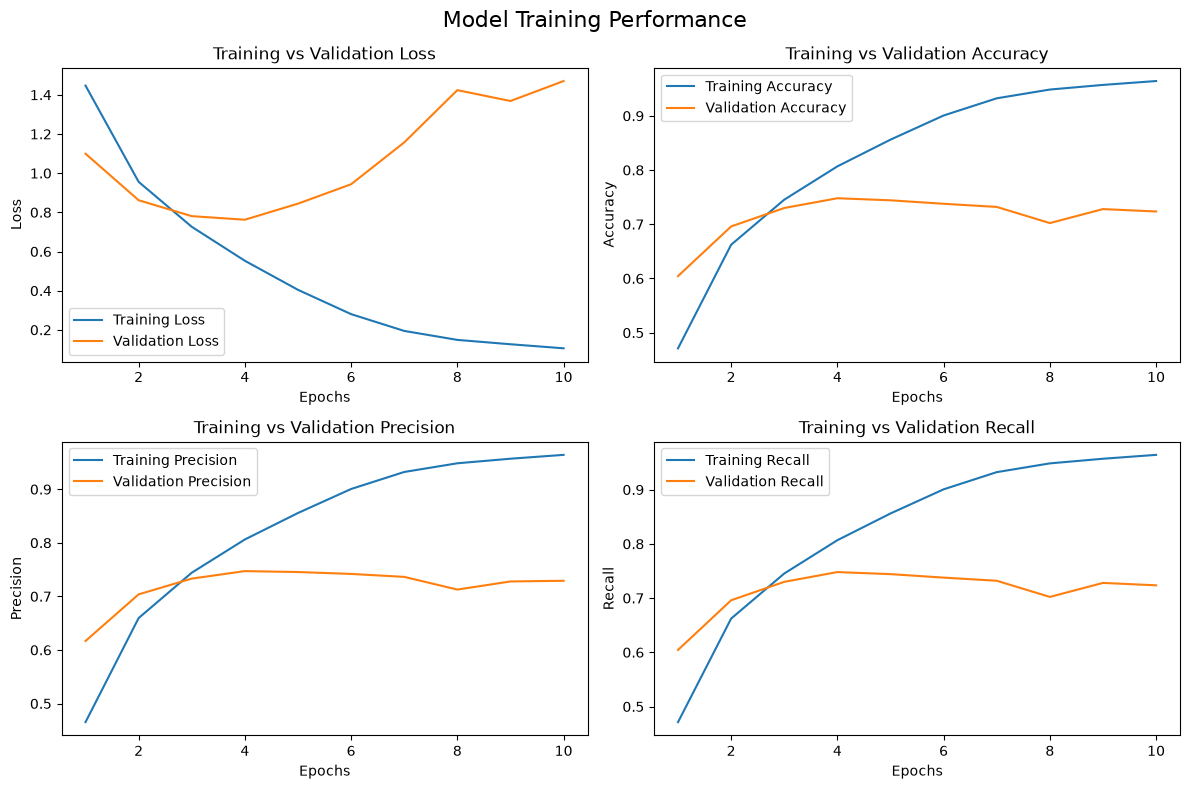

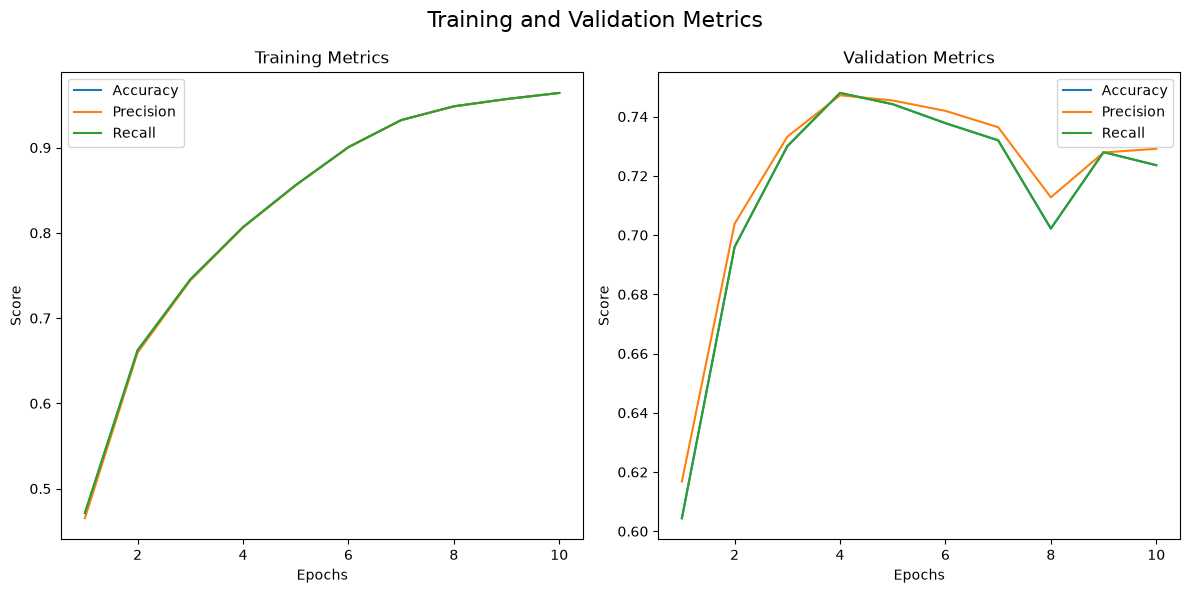

In [6]:
from src.plots import plot_all_metrics, plot_performance

plot_all_metrics(history=history)
plot_performance(history=history)